#### [실전] 타이타닉 생존율 예측 모형을 위한 데이터 파악

In [2]:
import pandas as pd
titanic_url='https://github.com/sehakflower/data/blob/main/titanic_1309.xlsx?raw=true'
titanic=pd.read_excel(titanic_url, sheet_name='total')
titanic_df=titanic.drop(['body', 'home.dest'], axis=1)
titanic_df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN


### 연령별 생존율 파악하기

In [3]:
##  include_lowest :   0 ~ 3 세 구간에서 0 을 포함.   pd.cut 은 기본적으로 왼쪽 제외 / 오른쪽 포함의 구조 이다.
titanic_df['age_cat']=pd.cut(titanic_df['age'], bins=[0, 3, 7, 15, 30, 60, 100], include_lowest=True, labels=['baby', 'children', 'teenage', 'young',
'adult', 'old'])

titanic_df.head(10)

#titanic_df.groupby('age_cat').mean(numeric_only=True)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,age_cat
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,young
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,baby
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,baby
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,young
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,young
5,1,1,"Anderson, Mr. Harry",male,48.0000,0,0,19952,26.5500,E12,S,3,adult
6,1,1,"Andrews, Miss. Kornelia Theodosia",female,63.0000,1,0,13502,77.9583,D7,S,10,old
7,1,0,"Andrews, Mr. Thomas Jr",male,39.0000,0,0,112050,0.0000,A36,S,NaN,adult
8,1,1,"Appleton, Mrs. Edward Dale (Charlotte Lamson)",female,53.0000,2,0,11769,51.4792,C101,S,D,adult
9,1,0,"Artagaveytia, Mr. Ramon",male,71.0000,0,0,PC 17609,49.5042,NaN,C,NaN,old


In [ ]:
# 주피터 노트북 사용자
%pip install seaborn
%pip install matplotlib
# uv
uv add seaborn matplotlib

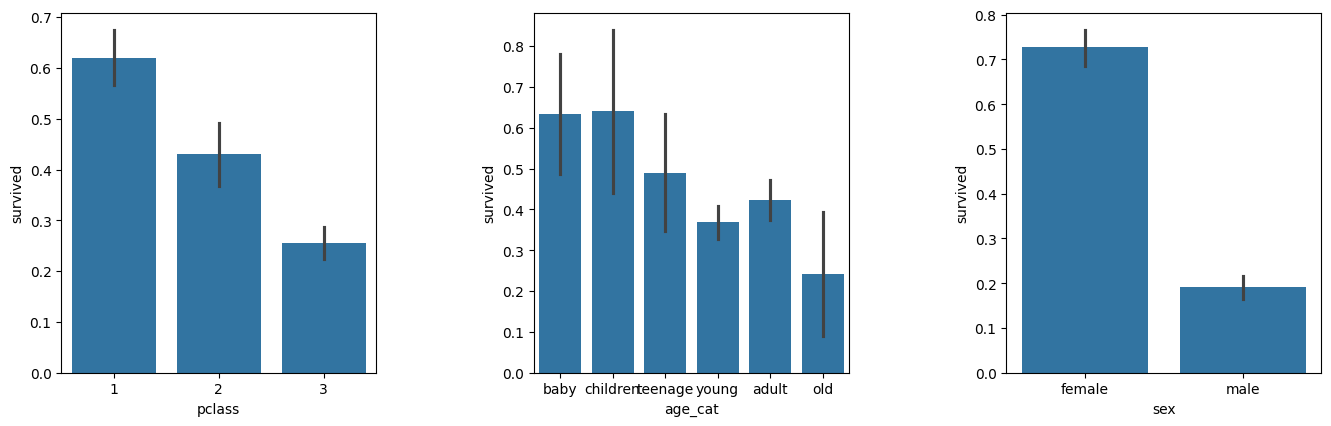

In [ ]:
### bar 중간에 있는 검은 선은 CI (confidence interval) - 신뢰 구간. 즉, 95% 의 신뢰 구간

import seaborn as sns
#%matplotlib inline
from matplotlib import pyplot as plt

data=titanic_df
plt.figure(figsize=[14, 4])             # 전체 graph 의 크기 (가로 14, 세로 4)

# 1행 3열의 1번째
plt.subplot(131)    























\\\\\\\\\\





























































































\\























































































sns.barplot(x='pclass', y='survived', data=titanic_df)

# 1행 3열의 2번째
plt.subplot(132)
sns.barplot(x='age_cat',y='survived', data=titanic_df)

# 1행 3열의 3번째
plt.subplot(133)
sns.barplot(x='sex', y='survived', data=titanic_df)

plt.subplots_adjust(top=1, bottom=0.1, left=0.10, right=1, hspace=0.5, wspace=0.5)
plt.show( )

In [ ]:
import seaborn as sns
from matplotlib import pyplot as plt

# fig(figure):  전체 canvas,  subplots: 개별 칸 (subplots)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

fig.suptitle('Titanic Survival Analysis', fontsize=16)

sns.barplot(x='pclass', y='survived', data=titanic_df, ax=axes[0], color='red')
sns.barplot(x='age_cat', y='survived', data=titanic_df, ax=axes[1], color='skyblue')
sns.barplot(x='sex', y='survived', data=titanic_df, ax=axes[2])

plt.tight_layout() # 자동으로 간격을 최적화해주는 편리한 함수

plt.show()

In [ ]:
titanic_df.groupby(['pclass', 'sex']).mean(numeric_only=True )

In [ ]:
boat_survivors=titanic_df[titanic_df['boat'].notnull( )]        # 보트 탑승자
nboat_survivors=titanic_df[titanic_df['boat'].isnull( )]        # 보트 탑승 못한 사람

print(boat_survivors.groupby('sex')['survived'].mean( ))
print(nboat_survivors.groupby('sex')['survived'].mean( ))

# pandas.api.SeriesGroupBy object 는 그룹화 한 상태이고
# 그 뒤에 집계 함수 count, mean 등을 붙여 줘야 함
boat_survivors.groupby('sex')['survived'].count()
#nboat_survivors.groupby('sex')['survived'].count()



In [ ]:
f, ax=plt.subplots(1, 2, figsize=(12, 6))

ax[0].set_title('Survived')
ax[0].set_ylabel('')
boat_survivors['survived'].value_counts( ).plot.pie(explode=[0,0.1], autopct='%1.2f%%', ax=ax[0])

ax[1].set_title('Survived')
sns.countplot(x='survived', data=boat_survivors, ax=ax[1])

plt.show( )

### 귀족 계급의 생존율 파악하기

In [ ]:
conversion_special=lambda x: x.split(',')[1].split('.')[0].strip( )
titanic_df['title']=titanic_df['name'].map(conversion_special)
titanic_df['title']=titanic_df['title'].replace('Mlle', 'Miss')
titanic_df['title']=titanic_df['title'].replace('Ms', 'Miss')
titanic_df['title']=titanic_df['title'].replace('Mme', 'Mrs')
Special=['Lady', 'the Countess', 'Countess', 'Capt', 'Master', 'Col', 'Don', 'Dr', 'Major',
'Rev', 'Sir', 'Jonkheer', 'Dona']
for each in Special:
  titanic_df['title']=titanic_df['title'].replace(each, 'Special')
print(titanic_df[['title', 'survived']].groupby(['title'], as_index=False).mean( ))

In [ ]:
titanic_df.groupby(['sex', 'title']).mean(numeric_only=True )